In [1]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
!pip install -q \
    "diffusers==0.35.1" \
    "transformers==4.55.4" \
    "accelerate==1.10.1" \
    "bitsandbytes==0.46.1" \
    "safetensors>=0.5.3"

In [9]:
import torch
import torchvision
import transformers
import diffusers
import accelerate
import bitsandbytes

print("=" * 65)
print("ENVIRONMENT")
print("=" * 65)

print("PyTorch       :", torch.__version__)
print("Torchvision   :", torchvision.__version__)
print("Transformers  :", transformers.__version__)
print("Diffusers     :", diffusers.__version__)
print("Accelerate    :", accelerate.__version__)
print("Bitsandbytes  :", bitsandbytes.__version__)
print("CUDA          :", torch.version.cuda)
print()

print("CUDA available:", torch.cuda.is_available())
print("GPU count     :", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(
        f"GPU {i}:",
        torch.cuda.get_device_name(i)
    )

print("=" * 65)

# Test quan trọng nhất
from transformers import CLIPImageProcessor

print()
print("CLIPImageProcessor import: OK")

from diffusers import DiffusionPipeline

print("DiffusionPipeline import: OK")

print()
print("Environment looks OK.")


ENVIRONMENT
PyTorch       : 2.10.0+cu128
Torchvision   : 0.25.0+cu128
Transformers  : 4.55.4
Diffusers     : 0.35.1
Accelerate    : 1.10.1
Bitsandbytes  : 0.46.1
CUDA          : 12.8

CUDA available: True
GPU count     : 2
GPU 0: Tesla T4
GPU 1: Tesla T4

CLIPImageProcessor import: OK
DiffusionPipeline import: OK

Environment looks OK.
1


FLUX.1-dev — 4-bit
PyTorch : 2.10.0+cu128
CUDA    : 12.8
GPU     : 2
GPU 0 : Tesla T4
GPU 1 : Tesla T4

Loading quantized FLUX transformer...



Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


Loading pipeline...



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers



GENERATING
Prompt : a tiny astronaut hatching from an egg on the moon
Size   : 1024x1024
Steps  : 28
CFG    : 3.5
Seed   : 0



  0%|          | 0/28 [00:00<?, ?it/s]


DONE
Saved: /kaggle/working/outputs/flux1.png


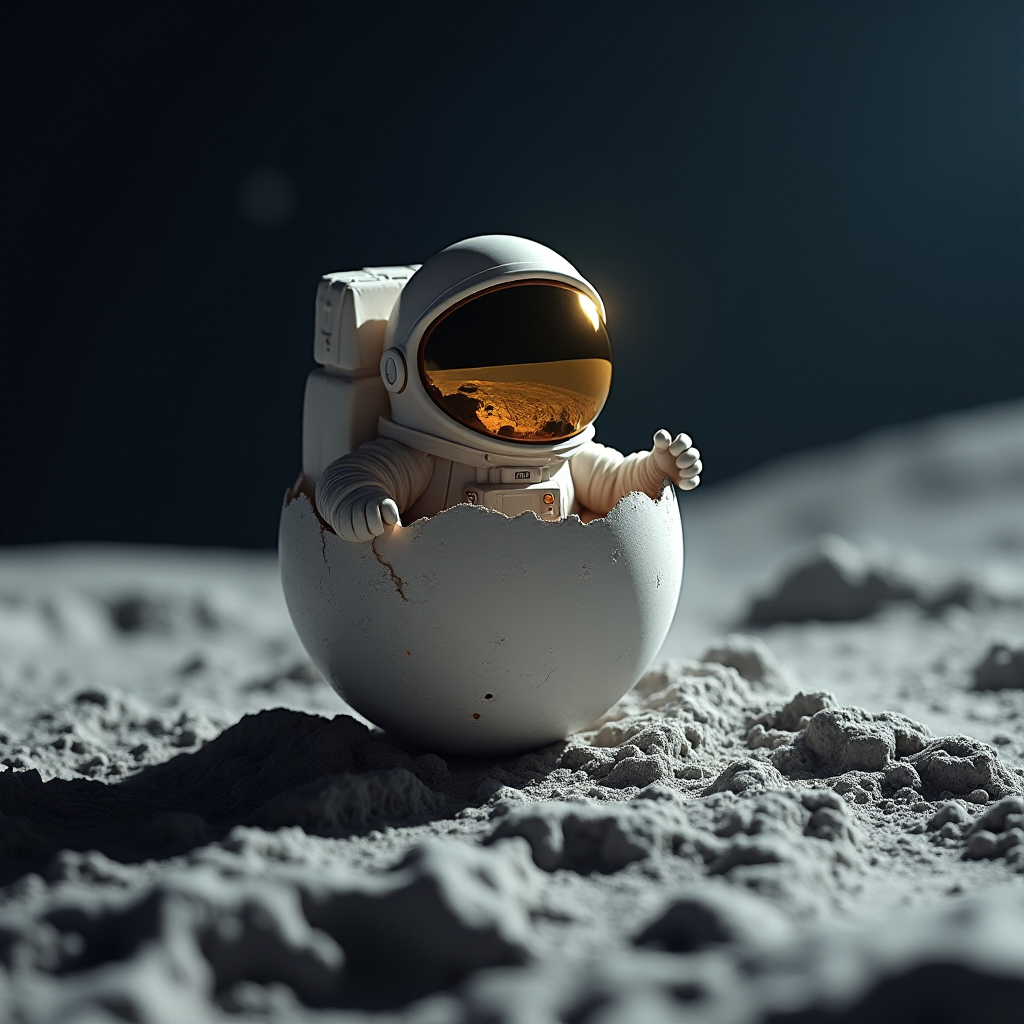

In [6]:
# ============================================================
# FLUX.1-dev — Kaggle 2x T4
# 4-bit Transformer + FP16 text encoders
# ============================================================

import torch
from pathlib import Path

from transformers import BitsAndBytesConfig
from diffusers import (
    DiffusionPipeline,
    FluxTransformer2DModel,
)


# ============================================================
# CONFIG
# ============================================================

MODEL_ID = "black-forest-labs/FLUX.1-dev"

PROMPT = "a tiny astronaut hatching from an egg on the moon"

STEPS = 28
GUIDANCE = 3.5
SEED = 0

WIDTH = 1024
HEIGHT = 1024

OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "flux1.png"


# ============================================================
# GPU CHECK
# ============================================================

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU không khả dụng.")

N = torch.cuda.device_count()

print("=" * 65)
print("FLUX.1-dev — 4-bit")
print("=" * 65)

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.version.cuda)
print("GPU     :", N)

for i in range(N):
    print(f"GPU {i} :", torch.cuda.get_device_name(i))

print("=" * 65)


# ============================================================
# 4-BIT CONFIG
# ============================================================

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)


# ============================================================
# LOAD QUANTIZED TRANSFORMER
# ============================================================

print()
print("Loading quantized FLUX transformer...")
print()

transformer = FluxTransformer2DModel.from_pretrained(
    MODEL_ID,
    subfolder="transformer",
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
)


# ============================================================
# LOAD PIPELINE
# ============================================================

print()
print("Loading pipeline...")
print()

pipe = DiffusionPipeline.from_pretrained(
    MODEL_ID,
    transformer=transformer,
    torch_dtype=torch.float16,
)


# ============================================================
# DEVICE
# ============================================================

# Với 2 T4, để Accelerate tự quản lý CPU/GPU.
#
# Không dùng:
# device_map="balanced"
#
# ở đây.

pipe.enable_model_cpu_offload()


# ============================================================
# MEMORY OPTIMIZATION
# ============================================================

if hasattr(pipe, "enable_vae_slicing"):
    pipe.enable_vae_slicing()

if hasattr(pipe, "enable_vae_tiling"):
    pipe.enable_vae_tiling()


# ============================================================
# GENERATE
# ============================================================

print()
print("=" * 65)
print("GENERATING")
print("=" * 65)

print("Prompt :", PROMPT)
print("Size   :", f"{WIDTH}x{HEIGHT}")
print("Steps  :", STEPS)
print("CFG    :", GUIDANCE)
print("Seed   :", SEED)
print()


generator = torch.Generator(
    device="cpu"
).manual_seed(SEED)


with torch.inference_mode():

    result = pipe(
        prompt=PROMPT,
        height=HEIGHT,
        width=WIDTH,
        guidance_scale=GUIDANCE,
        num_inference_steps=STEPS,
        max_sequence_length=512,
        generator=generator,
    )


# ============================================================
# SAVE
# ============================================================

image = result.images[0]

image.save(OUTPUT_PATH)

print()
print("=" * 65)
print("DONE")
print("=" * 65)

print("Saved:", OUTPUT_PATH)

display(image)
